# Scenario 2: Evaporation and Precipitation

The circulation in our model is currently `forced' by both atmospheric temperature above each surface box, and evaporative balance (evaporation - precipitation) which moves fresh water from the low to high latitudes. The atmospheric temperatures, as well as the amount of evaporation/precipitation are fixed at constant values. In reality, both atmospheric temperature and evaporation/precipitation are sensitive to the state of the climate. In this question, you will consider how changes in evaporation and precipitation impact the behaviour of the model.

As the planet warms, we expect greater evaporation in the warm low latitudes, which is likely to lead to more precipitation in the high latitudes. We can approximate this in the model by making the low-latitude evaporation-precipitation balance ($F_w$) sensitive to the amount of $\mathrm{pCO_2}$ in the atmosphere. We can write this as:

$$
F_w = 0.1 + \beta \left( \frac{\mathrm{pCO_2}}{\mathrm{pCO_{2(ref)}}} - 1 \right)
$$

Where $F_w$ is the net precipitatoin-evaporation balance in the low latitude box (in m), $\mathrm{pCO_{2(ref)}}$ is the steady state $\mathrm{pCO_2}$ of your original model, and $\beta$ describes the change in precipitation-evaporation balance per doubling in $\mathrm{pCO_2}$.

Include the sensitivity of $F_w$ to $\mathrm{pCO_2}$, and its consequent impact on circulation strength, $Q$, in your model, and address the following questions:

1. Set the $\beta$ value to 0.01, which is a 10\% increase in low-latitude evaporation-precipitation per doubling of $\mathrm{pCO_2}$. Conduct a $\mathrm{CO_2}$ release experiment, where $\mathrm{8~GtC~yr^{-1}}$ is emitted into the atmosphere for 200 years (between model years 400-600). Run the model to steady-state, and examine the evolution of $T$, $S$ and circulation processes compared to the original model?. How do $F_w$ and $Q$ change in response to the $\mathrm{CO_2}$ release experiment? What impact does this new feedback have on the residence time of water in the surface boxes?
2. How does this new feedback mechanism alter the fate of the $\mathrm{CO_2}$ released into the atmosphere? Discuss the mechanisms behind the changes you observe.
3. How realistic is your simulation of evaporation/precipitation changes? What additional factors might influence how these patterns manifest in the real ocean?


## Model Set-Up

In [143]:
# This code installs some required packages for the rest of the notebook. Run this once at the start - it should take <30 seconds to run.
#%%capture
import os
if not os.path.exists('./OceanTools'):
    !git clone https://github.com/Quantitative-Environmental-Science/OceanTools.git

import sys
sys.path.append('./OceanTools')

!pip install cbsyst

import numpy as np
import matplotlib.pyplot as plt
from cbsyst import Csys  # this is for carbon chemistry calculations

In [144]:
# global variables
V_ocean = 1.34e18  # volume of the ocean in m3
SA_ocean = 358e12  # surface area of the ocean in m2
fSA_hilat = 0.15  # fraction of ocean surface area in 'high latitude' box

# variables used to calculate Q
Q_alpha = 1e-4
Q_beta = 7e-4
Q_k = 8.3e17

# salinity balance - the total amount of salt added or removed to the surface boxes
Fw = 0.1  # low latitude evaporation - precipitation in units of m yr-1
Sref = 35  # reference salinity in units of g kg-1
E = Fw * SA_ocean * (1 - fSA_hilat) * Sref  # amount of salt removed from the low latitude box,  g kg-1 yr-1, ~ kg m-3 yr-1

In [145]:
# NOTE: Initial DIC, TA, PO4 and pCO2 values are set to steady state values from the unmodified model.

init_hilat = {
    'name': 'hilat',
    'depth': 200,  # box depth, m
    'SA': SA_ocean * fSA_hilat,  # box surface area, m2
    'T': 3.897678,  # initial water temperature, Celcius
    'S': 34.37786,  # initial salinity
    'T_atmos': 0.,  # air temperature, Celcius
    'tau_M': 100.,  # timescale of surface-deep mixing, yr
    'tau_T': 2.,  # timescale of temperature exchange with atmosphere, yr
    'E': -E,  # salt added due to evaporation - precipitation, kg m-3 yr-1
    'tau_CO2': 2.,  # timescale of CO2 exchange, yr
    'DIC': 2.02837,  # Dissolved Inorganic Carbon concentration, mol m-3
    'TA': 2.22116,  # Total Alkalinity, mol m-3
    'tau_PO4': 3.,  # phosphate half life, yr at initial f_CaCO3
    'PO4': 8.8995e-5,  # Phosphate conc, mol m-3
    'f_CaCO3': 0.2,  # fraction of organic matter export that produces CaCO3 at starting [CO3]
}
init_hilat['V'] = init_hilat['SA'] *  init_hilat['depth']  # box volume, m3

init_lolat = {
    'name': 'lolat',
    'depth': 100,  # box depth, m
    'SA': SA_ocean * (1 - fSA_hilat),  # box surface area, m2
    'T': 23.60040,  # initial water temperature, Celcius
    'S': 35.37898,  # initial salinity
    'T_atmos': 25.,  # air temperature, Celcius
    'tau_M': 250.,  # timescale of surface-deep mixing, yr
    'tau_T': 2.,  # timescale of temperature exchange with atmosphere, yr
    'E': E,  # salinity balance, PSU m3 yr-1
    'tau_CO2': 2.,  # timescale of CO2 exchange, yr
    'DIC': 1.99405,  # Dissolved Inorganic Carbon concentration, mol m-3
    'TA': 2.21883,  # Total Alkalinity, mol m-3
    'tau_PO4': 2.,  # phosphate half life, yr at initial f_CaCO3
    'PO4': 1.6541e-4,  # Phosphate conc, mol m-3
    'f_CaCO3': 0.3,  # fraction of organic matter export that produces CaCO3 at starting [CO3]
}
init_lolat['V'] = init_lolat['SA'] *  init_lolat['depth']  # box volume, m3

init_deep = {
    'name': 'deep',
    'V': V_ocean - init_lolat['V'] - init_hilat['V'],  # box volume, m3
    'T': 5.483637,  # initial water temperature, Celcius
    'S': 34.47283,  # initial salinity
    'DIC': 2.32712,  # Dissolved Inorganic Carbon concentration, mol m-3
    'TA': 2.31640,  # Total Alkalinity, mol m-3
    'PO4': 2.30515e-3,  # Phosphate conc, mol m-3
}

init_atmos = {
    'name': 'atmos',
    'mass': 5.132e18,  # kg
    'moles_air': 1.736e20,  # moles
    'moles_CO2': 872e15 / 12,  # moles
    'GtC_emissions': 0.0  # annual emissions of CO2 into the atmosphere, GtC
}
init_atmos['pCO2'] = init_atmos['moles_CO2'] / init_atmos['moles_air'] * 1e6

### Original Model Code

The function below contains the full code for the model you have developed in the last three practicals. This should be the 'baseline' model that you will use as a comparison point for your new model.

In [146]:
def ocean_model(lolat, hilat, deep, atmos, tmax, dt):

    # create the time scale for the model
    time = np.arange(0, tmax + dt, dt)

    # identify which variables will change with time
    model_vars = ['T', 'S', 'DIC', 'TA', 'PO4']
    atmos_model_vars = ['moles_CO2', 'pCO2']

    # create copies of the input dictionaries so we don't modify the originals
    lolat = lolat.copy()
    hilat = hilat.copy()
    deep = deep.copy()
    atmos = atmos.copy()

    # turn all time-evolving variables into arrays containing the start values
    for box in [lolat, hilat, deep]:
        for k in model_vars:
            box[k] = np.full(time.shape, box[k])
    for box in [lolat, hilat]:
        box['Q'] = np.full(time.shape, np.nan)
    # Store vmix fluxes for all tracers
    for tracer in ['T', 'S', 'DIC', 'TA', 'PO4']:
        lolat[f'vmix_{tracer}'] = np.zeros_like(time)
        hilat[f'vmix_{tracer}'] = np.zeros_like(time)
    for k in atmos_model_vars:
        atmos[k] = np.full(time.shape, atmos[k])
    if isinstance(atmos['GtC_emissions'], (int, float)):
        atmos['GtC_emissions'] = np.full(time.shape, atmos['GtC_emissions'])

    # calculate initial surface carbon chemistry in the surface boxes using Csys, and store a few key variables - CO2, pH, pCO2 and K0
    for box in [lolat, hilat]:
        csys = Csys(
            TA=box['TA'], DIC=box['DIC'],
            T_in=box['T'], S_in=box['S'],
            unit='mmol'  # we specify mmol here because mol m-3 is the same as mmol L-1, and Csys works in L-1
            )
        box['CO2'] = csys.CO2
        box['pH'] = csys.pHtot
        box['pCO2'] = csys.pCO2
        box['K0'] = csys.Ks.K0

    # Create a dictionary to keep track of the fluxes calculated at each step
    fluxes = {}

    for i in range(1, time.size):
        last = i - 1  # index of last model step

        # calculate circulation flux, Q
        dT = lolat['T'][last] - hilat['T'][last]
        dS = lolat['S'][last] - hilat['S'][last]
        Q = Q_k * (Q_alpha * dT - Q_beta * dS)

        # calculate mixing fluxes for model variables
        for var in model_vars:
            fluxes[f'Q_{var}_deep'] = Q * (hilat[var][last] - deep[var][last]) * dt  # mol dt-1
            fluxes[f'Q_{var}_hilat'] = Q * (lolat[var][last] - hilat[var][last]) * dt  # mol dt-1
            fluxes[f'Q_{var}_lolat'] = Q * (deep[var][last] - lolat[var][last]) * dt  # mol dt-1

            fluxes[f'vmix_{var}_hilat'] = hilat['V'] / hilat['tau_M'] * (hilat[var][last] - deep[var][last]) * dt  # mol dt-1
            fluxes[f'vmix_{var}_lolat'] = lolat['V'] / lolat['tau_M'] * (lolat[var][last] - deep[var][last]) * dt  # mol dt-1

        for tracer in ['T', 'S', 'DIC', 'TA', 'PO4']:
            lolat[f'vmix_{tracer}'][i] = fluxes[f'vmix_{tracer}_lolat']
            hilat[f'vmix_{tracer}'][i] = fluxes[f'vmix_{tracer}_hilat']

        # calculate surface-specific fluxes
        for box in [hilat, lolat]:
            boxname = box['name']
            # temperature exchange with atmosphere
            fluxes[f'dT_{boxname}'] = box['V'] / box['tau_T'] * (box['T_atmos'] - box['T'][last]) * dt  # mol dt-1
            # CO2 exchange with atmosphere
            fluxes[f'dCO2_{boxname}'] = box['V'] / box['tau_CO2'] * (box['CO2'][last] - 1e-3 * atmos['pCO2'][last] * box['K0'][last]) * dt  # mol dt-1
            # organic matter production
            fluxes[f'export_PO4_{boxname}'] = box['PO4'][last] * box['V'] / box['tau_PO4'] * dt  # mol PO4 dt-1
            # DIC export by productivity :                                  redfield + calcification
            fluxes[f'export_DIC_{boxname}'] = fluxes[f'export_PO4_{boxname}'] * (106 + 106 * box['f_CaCO3'])  # mol DIC dt-1
            # TA export by productivity :                                  redfield + calcification
            fluxes[f'export_TA_{boxname}'] = fluxes[f'export_PO4_{boxname}'] * (-18 + 2 * 106 * box['f_CaCO3'])  # mol TA dt-1

        fluxes['dCO2_emissions'] = atmos['GtC_emissions'][last] * 1e15 / 12 * dt  # mol dt-1

        # update deep box
        for var in model_vars:
            if var in ['T', 'S']:
                deep[var][i] = deep[var][last] + (
                    fluxes[f'Q_{var}_deep'] + fluxes[f'vmix_{var}_hilat'] + fluxes[f'vmix_{var}_lolat']
                ) / deep['V']
            else:
                deep[var][i] = deep[var][last] + (
                    fluxes[f'Q_{var}_deep'] + fluxes[f'vmix_{var}_hilat'] + fluxes[f'vmix_{var}_lolat'] + fluxes[f'export_{var}_hilat'] + fluxes[f'export_{var}_lolat']
                ) / deep['V']

        # update surface boxes
        for box in [hilat, lolat]:
            boxname = box['name']
            box['S'][i] = box['S'][last] + (fluxes[f'Q_S_{boxname}'] - fluxes[f'vmix_S_{boxname}'] + box['E'] * dt) / box['V']
            box['T'][i] = box['T'][last] + (fluxes[f'Q_T_{boxname}'] - fluxes[f'vmix_T_{boxname}'] + fluxes[f'dT_{boxname}']) / box['V']
            box['DIC'][i] = box['DIC'][last] + (fluxes[f'Q_DIC_{boxname}'] - fluxes[f'vmix_DIC_{boxname}'] - fluxes[f'dCO2_{boxname}'] - fluxes[f'export_DIC_{boxname}']) / box['V']
            box['TA'][i] = box['TA'][last] + (fluxes[f'Q_TA_{boxname}'] - fluxes[f'vmix_TA_{boxname}'] - fluxes[f'export_TA_{boxname}']) / box['V']
            box['PO4'][i] = box['PO4'][last] + (fluxes[f'Q_PO4_{boxname}'] - fluxes[f'vmix_PO4_{boxname}'] - fluxes[f'export_PO4_{boxname}']) / box['V']

            # update carbon speciation
            csys = Csys(
                TA=box['TA'][i], DIC=box['DIC'][i],
                T_in=box['T'][i], S_in=box['S'][i],
                unit='mmol'
                )
            box['CO2'][i] = csys.CO2[0]
            box['pH'][i] = csys.pHtot[0]
            box['pCO2'][i] = csys.pCO2[0]
            box['K0'][i] = csys.Ks.K0

        # update atmosphere
        atmos['moles_CO2'][i] = atmos['moles_CO2'][last] + fluxes['dCO2_hilat'] + fluxes['dCO2_lolat'] + fluxes['dCO2_emissions']
        atmos['pCO2'][i] = 1e6 * atmos['moles_CO2'][i] / atmos['moles_air']

    return time, lolat, hilat, deep, atmos

lolat: 520.01
hilat: 265.96
atmos: 418.04


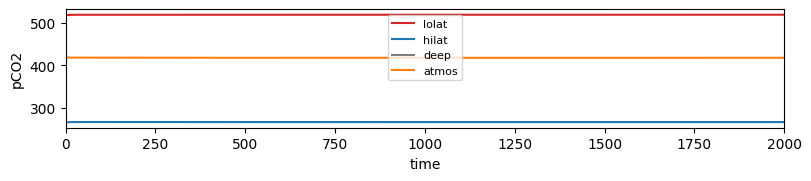

In [147]:
# perform baseline model run
otime, ololat, ohilat, odeep, oatmos = ocean_model(init_lolat, init_hilat, init_deep, init_atmos, 2000, 0.5)

from tools import plot
from tools.helpers import get_last_values

plot.boxes(otime, ['pCO2'], ololat, ohilat, odeep, oatmos)

for k, v in get_last_values(ololat, ohilat, oatmos).items():
    print(f"{k}: {v['pCO2']:.2f}")

### Modify the Model Below

In [148]:
pCO2_ref = oatmos['pCO2'][-1]

def new_ocean_model(lolat, hilat, deep, atmos, tmax, dt):

    # create the time scale for the model
    time = np.arange(0, tmax + dt, dt)

    # identify which variables will change with time
    model_vars = ['T', 'S', 'DIC', 'TA', 'PO4']
    atmos_model_vars = ['moles_CO2', 'pCO2']

    # create copies of the input dictionaries so we don't modify the originals
    lolat = lolat.copy()
    hilat = hilat.copy()
    deep = deep.copy()
    atmos = atmos.copy()

    # turn all time-evolving variables into arrays containing the start values
    for box in [lolat, hilat, deep]:
        for k in model_vars:
            box[k] = np.full(time.shape, box[k])
    for box in [lolat, hilat]:
        box['E'] = np.full(time.shape, np.nan)
        box['Fw'] = np.full(time.shape, np.nan)
        box['Q'] = np.full(time.shape, np.nan)
    for k in atmos_model_vars:
        atmos[k] = np.full(time.shape, atmos[k])
    if isinstance(atmos['GtC_emissions'], (int, float)):
        atmos['GtC_emissions'] = np.full(time.shape, atmos['GtC_emissions'])

    # calculate initial surface carbon chemistry in the surface boxes using Csys, and store a few key variables - CO2, pH, pCO2 and K0
    for box in [lolat, hilat]:
        csys = Csys(
            TA=box['TA'], DIC=box['DIC'],
            T_in=box['T'], S_in=box['S'],
            unit='mmol'  # we specify mmol here because mol m-3 is the same as mmol L-1, and Csys works in L-1
            )
        box['CO2'] = csys.CO2
        box['pH'] = csys.pHtot
        box['pCO2'] = csys.pCO2
        box['K0'] = csys.Ks.K0

    # Create a dictionary to keep track of the fluxes calculated at each step
    fluxes = {}

    for i in range(1, time.size):
        last = i - 1  # index of last model step

        # calculate low-latitude evaporation - precipitation
        Fw = 0.1 + 0.01 * (atmos['pCO2'][last] / pCO2_ref - 1)
        E = Fw * lolat['SA'] * lolat['S'][last]  # amount of salt removed from the low latitude box,  g kg-1 yr-1, ~ kg m-3 yr-1

        lolat['Fw'][i] = Fw

        lolat['E'][i] = E
        hilat['E'][i] = -E

        # calculate circulation flux, Q
        dT = lolat['T'][last] - hilat['T'][last]
        dS = lolat['S'][last] - hilat['S'][last]
        Q = Q_k * (Q_alpha * dT - Q_beta * dS)

        lolat['Q'][i] = Q
        hilat['Q'][i] = Q

        # calculate mixing fluxes for model variables
        for var in model_vars:
            fluxes[f'Q_{var}_deep'] = Q * (hilat[var][last] - deep[var][last]) * dt  # mol dt-1
            fluxes[f'Q_{var}_hilat'] = Q * (lolat[var][last] - hilat[var][last]) * dt  # mol dt-1
            fluxes[f'Q_{var}_lolat'] = Q * (deep[var][last] - lolat[var][last]) * dt  # mol dt-1

            fluxes[f'vmix_{var}_hilat'] = hilat['V'] / hilat['tau_M'] * (hilat[var][last] - deep[var][last]) * dt  # mol dt-1
            fluxes[f'vmix_{var}_lolat'] = lolat['V'] / lolat['tau_M'] * (lolat[var][last] - deep[var][last]) * dt  # mol dt-1

        # calculate surface-specific fluxes
        for box in [hilat, lolat]:
            boxname = box['name']
            # temperature exchange with atmosphere
            fluxes[f'dT_{boxname}'] = box['V'] / box['tau_T'] * (box['T_atmos'] - box['T'][last]) * dt  # mol dt-1
            # CO2 exchange with atmosphere
            fluxes[f'dCO2_{boxname}'] = box['V'] / box['tau_CO2'] * (box['CO2'][last] - 1e-3 * atmos['pCO2'][last] * box['K0'][last]) * dt  # mol dt-1
            # organic matter production
            fluxes[f'export_PO4_{boxname}'] = box['PO4'][last] * box['V'] / box['tau_PO4'] * dt  # mol PO4 dt-1
            # DIC export by productivity :                                  redfield + calcification
            fluxes[f'export_DIC_{boxname}'] = fluxes[f'export_PO4_{boxname}'] * (106 + 106 * box['f_CaCO3'])  # mol DIC dt-1
            # TA export by productivity :                                  redfield + calcification
            fluxes[f'export_TA_{boxname}'] = fluxes[f'export_PO4_{boxname}'] * (-18 + 2 * 106 * box['f_CaCO3'])  # mol TA dt-1
            
        fluxes['dCO2_emissions'] = atmos['GtC_emissions'][last] * 1e15 / 12 * dt  # mol dt-1

        # update deep box
        for var in model_vars:
            if var in ['T', 'S']:
                deep[var][i] = deep[var][last] + (
                    fluxes[f'Q_{var}_deep'] + fluxes[f'vmix_{var}_hilat'] + fluxes[f'vmix_{var}_lolat']
                ) / deep['V']
            else:
                deep[var][i] = deep[var][last] + (
                    fluxes[f'Q_{var}_deep'] + fluxes[f'vmix_{var}_hilat'] + fluxes[f'vmix_{var}_lolat'] + fluxes[f'export_{var}_hilat'] + fluxes[f'export_{var}_lolat']
                ) / deep['V']

        # update surface boxes
        for box in [hilat, lolat]:
            boxname = box['name']
            box['S'][i] = box['S'][last] + (fluxes[f'Q_S_{boxname}'] - fluxes[f'vmix_S_{boxname}'] + box['E'][i] * dt) / box['V']
            box['T'][i] = box['T'][last] + (fluxes[f'Q_T_{boxname}'] - fluxes[f'vmix_T_{boxname}'] + fluxes[f'dT_{boxname}']) / box['V']
            box['DIC'][i] = box['DIC'][last] + (fluxes[f'Q_DIC_{boxname}'] - fluxes[f'vmix_DIC_{boxname}'] - fluxes[f'dCO2_{boxname}'] - fluxes[f'export_DIC_{boxname}']) / box['V']
            box['TA'][i] = box['TA'][last] + (fluxes[f'Q_TA_{boxname}'] - fluxes[f'vmix_TA_{boxname}'] - fluxes[f'export_TA_{boxname}']) / box['V']
            box['PO4'][i] = box['PO4'][last] + (fluxes[f'Q_PO4_{boxname}'] - fluxes[f'vmix_PO4_{boxname}'] - fluxes[f'export_PO4_{boxname}']) / box['V']

            # update carbon speciation
            csys = Csys(
                TA=box['TA'][i], DIC=box['DIC'][i],
                T_in=box['T'][i], S_in=box['S'][i],
                unit='mmol'
                )
            box['CO2'][i] = csys.CO2[0]
            box['pH'][i] = csys.pHtot[0]
            box['pCO2'][i] = csys.pCO2[0]
            box['K0'][i] = csys.Ks.K0

        # update atmosphere
        atmos['moles_CO2'][i] = atmos['moles_CO2'][last] + fluxes['dCO2_hilat'] + fluxes['dCO2_lolat'] + fluxes['dCO2_emissions']
        atmos['pCO2'][i] = 1e6 * atmos['moles_CO2'][i] / atmos['moles_air']

    return time, lolat, hilat, deep, atmos

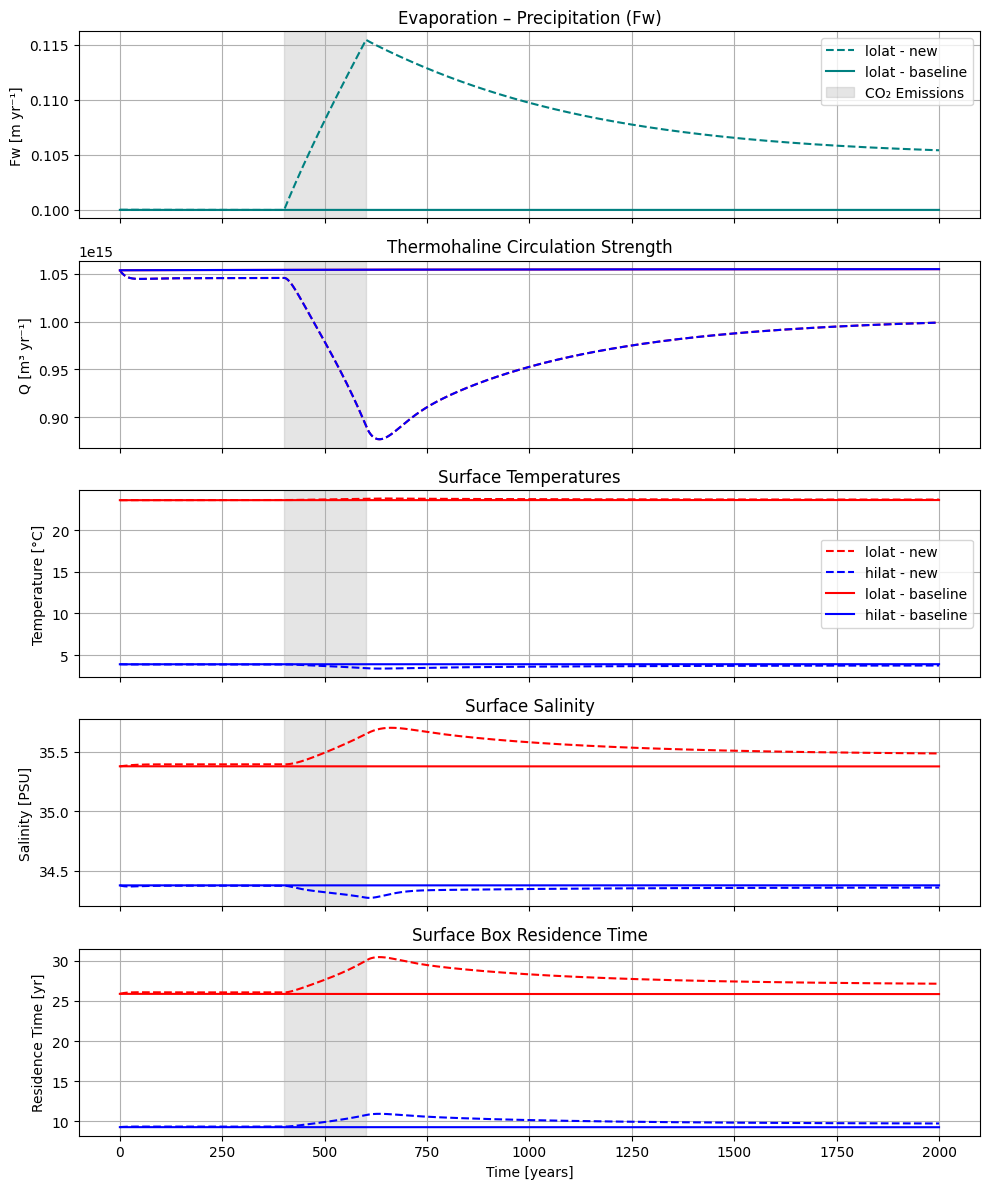

In [149]:
tmax = 2000
dt = 0.5
time = np.arange(0, tmax + dt, dt)

GtC_emissions = np.zeros_like(time)
GtC_emissions[(time > 400) & (time <= 600)] = 8.0  # 8 GtC/yr for 200 years

emit_lolat = init_lolat.copy()
emit_hilat = init_hilat.copy()
emit_deep = init_deep.copy()
emit_atmos = init_atmos.copy()
emit_atmos['GtC_emissions'] = GtC_emissions

# perform baseline model run
otime, ololat, ohilat, odeep, oatmos = ocean_model(emit_lolat, emit_hilat, emit_deep, emit_atmos, tmax, dt)

# perform new model run
et, elolat, ehilat, edeep, eatmos = new_ocean_model(emit_lolat, emit_hilat, emit_deep, emit_atmos, tmax, dt)

# Creating arrays for additional variables I want to plot
ololat['Fw'] = np.full_like(et, 0.1)
ololat['Q'] = Q_k * (Q_alpha * (ololat['T'] - ohilat['T']) - Q_beta * (ololat['S'] - ohilat['S']))
ohilat['Q'] = Q_k * (Q_alpha * (ololat['T'] - ohilat['T']) - Q_beta * (ololat['S'] - ohilat['S']))

# Calculate residence times for emissions model
lolat_V = elolat['V']
hilat_V = ehilat['V']
lolat_tauM = emit_lolat['tau_M']
hilat_tauM = emit_hilat['tau_M']

lolat_res_time = lolat_V / (elolat['Q'] + (lolat_V / lolat_tauM))
hilat_res_time = hilat_V / (ehilat['Q'] + (hilat_V / hilat_tauM))

# Calculate residence times for baseline model
lolat_V_base = ololat['V']
hilat_V_base = ohilat['V']
lolat_tauM_base = emit_lolat['tau_M']
hilat_tauM_base = emit_hilat['tau_M']

lolat_res_time_base = lolat_V_base / (ololat['Q'] + (lolat_V_base / lolat_tauM_base))
hilat_res_time_base = hilat_V_base / (ohilat['Q'] + (hilat_V_base / hilat_tauM_base))

# Plot variables to be analysed
import matplotlib.pyplot as plt

fig, axs = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

# Fw (only lolat has Fw)
axs[0].plot(et, elolat['Fw'], label='lolat - new', linestyle='--', color='teal')
axs[0].plot(et, ololat['Fw'], label='lolat - baseline', linestyle='-', color='teal')
axs[0].set_ylabel('Fw [m yr⁻¹]')
axs[0].set_title('Evaporation – Precipitation (Fw)')
axs[0].axvspan(400, 600, color='gray', alpha=0.2, label='CO₂ Emissions')
axs[0].legend()
axs[0].grid(True)

# Q (circulation, same in both boxes, but shown twice for clarity)
axs[1].plot(et, elolat['Q'], label='lolat Q - new', linestyle='--', color='red')
axs[1].plot(et, ehilat['Q'], label='hilat Q - new', linestyle='--', color='blue')
axs[1].plot(et, ololat['Q'], label='lolat Q - baseline', linestyle='-', color='red')
axs[1].plot(et, ohilat['Q'], label='hilat Q - baseline', linestyle='-', color='blue')
axs[1].set_ylabel('Q [m³ yr⁻¹]')
axs[1].set_title('Thermohaline Circulation Strength')
axs[1].axvspan(400, 600, color='gray', alpha=0.2)
axs[1].grid(True)

# Temperature
axs[2].plot(et, elolat['T'], label='lolat - new', linestyle='--', color='red')
axs[2].plot(et, ehilat['T'], label='hilat - new', linestyle='--', color='blue')
axs[2].plot(et, ololat['T'], label='lolat - baseline', linestyle='-', color='red')
axs[2].plot(et, ohilat['T'], label='hilat - baseline', linestyle='-', color='blue')
axs[2].set_ylabel('Temperature [°C]')
axs[2].set_title('Surface Temperatures')
axs[2].axvspan(400, 600, color='gray', alpha=0.2)
axs[2].legend()
axs[2].grid(True)

# Salinity
axs[3].plot(et, elolat['S'], label='lolat - new', linestyle='--', color='red')
axs[3].plot(et, ehilat['S'], label='hilat - new', linestyle='--', color='blue')
axs[3].plot(et, ololat['S'], label='lolat - baseline', linestyle='-', color='red')
axs[3].plot(et, ohilat['S'], label='hilat - baseline', linestyle='-', color='blue')
axs[3].set_ylabel('Salinity [PSU]')
axs[3].set_title('Surface Salinity')
axs[3].axvspan(400, 600, color='gray', alpha=0.2)
axs[3].grid(True)

# Residence Time
axs[4].plot(et, lolat_res_time, label='lolat - new', linestyle='--', color='red')
axs[4].plot(et, hilat_res_time, label='hilat - new', linestyle='--', color='blue')
axs[4].plot(et, lolat_res_time_base, label='lolat - baseline', linestyle='-', color='red')
axs[4].plot(et, hilat_res_time_base, label='hilat - baseline', linestyle='-', color='blue')
axs[4].axvspan(400, 600, color='gray', alpha=0.2, label='CO₂ Emissions')
axs[4].set_ylabel('Residence Time [yr]')
axs[4].set_xlabel('Time [years]')
axs[4].set_title('Surface Box Residence Time')
axs[4].grid(True)

plt.savefig('CO2_release_figure_1.png', dpi=1000, bbox_inches='tight')

plt.tight_layout()
plt.show()

How does Fw respond to CO2 emissions?

The most direct change the the model is the introduction of the new formula for Fw that relies on atmospheric pCO2. It is simple to predict the outcome demonstrated in the top pannel of the figure that as carbon dioxide is emitted into the atmosphere, the value of Fw increases linearly. After the emission period ends, the value of Fw relaxes at the same rate that atmospheric pCO2 relaxes (shown in figure 2). The cause for atmospheric pCO2 relaxing is the gradual absorption of the atmospheric carbon by the surface ocean boxes and then the transport of that carbon to the deep. The relaxation timescale depends on a combination of tau_CO2 and tau_M. The deep box is much more vast and has a higher capacity for long term storage, furthermore biological processes such as ballasting of organic matter result in locking up carbon permanently in the deep. The Fw value equilibrates at a higher value than before the emission period due to a portion of the added carbon remaining permanently in the atmosphere box.

How does Q (THC strength) respond to CO2 emissions?

Q depends on the temperature difference and the salinity difference between the two boxes, from the graphs we can see that the temperature difference barely changes however the salinity difference increases. Increasing salinity difference is explained by the increase in Fw during the emission period and leads to Q decreasing. When emissions stop, Q relaxes towards an equilibrium value lower than before the emissions, this is due to a permanent change in salinity difference caused by a consistently larger Fw which is explained by a permanent increase in atmospheric pCO2.

How does T respond to CO2 emissions?

Observing the T plot, it is clear that the surface box temperatures change only marginally, this is due to the strong forcing from the atmospheric temperature in each box which are held constant in this model. Small shifts in the equilibrium temperatures of each box are due to small shifts in the surface energy balance that are primarily caused by the change in equilibrium circulation strength, Q.

How does S respond to CO2 emissions?

S increases in the low latitude box due to increased evaporation (removal of pure water), but decreases in the high latitudes due to an increase in precipitation which dilutes the ocean. These shifts in evaporation and precipitation are driven by the value of Fw that is dependent on atmospheric pCO2. 

How do vertical mixing fluxes change over time?

Vertical mixing fluxes refer to the flow of water between the deep and surface boxes

How do residence times in the surface boxes change?

Residence times in the surface boxes increase due to a decrease in thermo-haline circulation strength Q. Residence time in the low latitude box increases much more than in the high latitude box, this is due to the low lat box having a larger volume and weaker vertical mixing (larger tau_M). Residence time = V / (Q + V/tau_M).

In [150]:
pCO2_ref = oatmos['pCO2'][-1]

def test_ocean_model(lolat, hilat, deep, atmos, tmax, dt):

    # create the time scale for the model
    time = np.arange(0, tmax + dt, dt)

    # identify which variables will change with time
    model_vars = ['T', 'S', 'DIC', 'TA', 'PO4']
    atmos_model_vars = ['moles_CO2', 'pCO2']

    # create copies of the input dictionaries so we don't modify the originals
    lolat = lolat.copy()
    hilat = hilat.copy()
    deep = deep.copy()
    atmos = atmos.copy()

    # turn all time-evolving variables into arrays containing the start values
    for box in [lolat, hilat, deep]:
        for k in model_vars:
            box[k] = np.full(time.shape, box[k])
    for box in [lolat, hilat]:
        box['E'] = np.full(time.shape, np.nan)
        box['Fw'] = np.full(time.shape, np.nan)
        box['Q'] = np.full(time.shape, np.nan)
    # Store vmix fluxes for all tracers
    for tracer in ['T', 'S', 'DIC', 'TA', 'PO4']:
        lolat[f'vmix_{tracer}'] = np.zeros_like(time)
        hilat[f'vmix_{tracer}'] = np.zeros_like(time)
    for k in atmos_model_vars:
        atmos[k] = np.full(time.shape, atmos[k])
    if isinstance(atmos['GtC_emissions'], (int, float)):
        atmos['GtC_emissions'] = np.full(time.shape, atmos['GtC_emissions'])

    # calculate initial surface carbon chemistry in the surface boxes using Csys, and store a few key variables - CO2, pH, pCO2 and K0
    for box in [lolat, hilat]:
        csys = Csys(
            TA=box['TA'], DIC=box['DIC'],
            T_in=box['T'], S_in=box['S'],
            unit='mmol'  # we specify mmol here because mol m-3 is the same as mmol L-1, and Csys works in L-1
            )
        box['CO2'] = csys.CO2
        box['pH'] = csys.pHtot
        box['pCO2'] = csys.pCO2
        box['K0'] = csys.Ks.K0

    # Create a dictionary to keep track of the fluxes calculated at each step
    fluxes = {}

    for i in range(1, time.size):
        last = i - 1  # index of last model step

        # calculate low-latitude evaporation - precipitation
        Fw = 0.1 + 0.01 * (atmos['pCO2'][last] / pCO2_ref - 1)
        E = Fw * lolat['SA'] * lolat['S'][last]  # amount of salt removed from the low latitude box,  g kg-1 yr-1, ~ kg m-3 yr-1

        lolat['Fw'][i] = Fw

        lolat['E'][i] = E
        hilat['E'][i] = -E

        # calculate circulation flux, Q
        dT = lolat['T'][last] - hilat['T'][last]
        dS = lolat['S'][last] - hilat['S'][last]
        Q = Q_k * (Q_alpha * dT - Q_beta * dS)

        lolat['Q'][i] = Q
        hilat['Q'][i] = Q

        # calculate mixing fluxes for model variables
        for var in model_vars:
            fluxes[f'Q_{var}_deep'] = Q * (hilat[var][last] - deep[var][last]) * dt  # mol dt-1
            fluxes[f'Q_{var}_hilat'] = Q * (lolat[var][last] - hilat[var][last]) * dt  # mol dt-1
            fluxes[f'Q_{var}_lolat'] = Q * (deep[var][last] - lolat[var][last]) * dt  # mol dt-1

            fluxes[f'vmix_{var}_hilat'] = hilat['V'] / hilat['tau_M'] * (hilat[var][last] - deep[var][last]) * dt  # mol dt-1
            fluxes[f'vmix_{var}_lolat'] = lolat['V'] / lolat['tau_M'] * (lolat[var][last] - deep[var][last]) * dt  # mol dt-1
        
        for tracer in ['T', 'S', 'DIC', 'TA', 'PO4']:
            lolat[f'vmix_{tracer}'][i] = fluxes[f'vmix_{tracer}_lolat']
            hilat[f'vmix_{tracer}'][i] = fluxes[f'vmix_{tracer}_hilat']


        # calculate surface-specific fluxes
        for box in [hilat, lolat]:
            boxname = box['name']
            # temperature exchange with atmosphere
            fluxes[f'dT_{boxname}'] = box['V'] / box['tau_T'] * (box['T_atmos'] - box['T'][last]) * dt  # mol dt-1
            # CO2 exchange with atmosphere
            fluxes[f'dCO2_{boxname}'] = box['V'] / box['tau_CO2'] * (box['CO2'][last] - 1e-3 * atmos['pCO2'][last] * box['K0'][last]) * dt  # mol dt-1
            # organic matter production
            fluxes[f'export_PO4_{boxname}'] = box['PO4'][last] * box['V'] / box['tau_PO4'] * dt  # mol PO4 dt-1
            # DIC export by productivity :                                  redfield + calcification
            fluxes[f'export_DIC_{boxname}'] = fluxes[f'export_PO4_{boxname}'] * (106 + 106 * box['f_CaCO3'])  # mol DIC dt-1
            # TA export by productivity :                                  redfield + calcification
            fluxes[f'export_TA_{boxname}'] = fluxes[f'export_PO4_{boxname}'] * (-18 + 2 * 106 * box['f_CaCO3'])  # mol TA dt-1
            
        fluxes['dCO2_emissions'] = atmos['GtC_emissions'][last] * 1e15 / 12 * dt  # mol dt-1

        # update deep box
        for var in model_vars:
            if var in ['T', 'S']:
                deep[var][i] = deep[var][last] + (
                    fluxes[f'Q_{var}_deep'] + fluxes[f'vmix_{var}_hilat'] + fluxes[f'vmix_{var}_lolat']
                ) / deep['V']
            else:
                deep[var][i] = deep[var][last] + (
                    fluxes[f'Q_{var}_deep'] + fluxes[f'vmix_{var}_hilat'] + fluxes[f'vmix_{var}_lolat'] + fluxes[f'export_{var}_hilat'] + fluxes[f'export_{var}_lolat']
                ) / deep['V']

        # update surface boxes
        for box in [hilat, lolat]:
            boxname = box['name']
            box['S'][i] = box['S'][last] + (fluxes[f'Q_S_{boxname}'] - fluxes[f'vmix_S_{boxname}'] + box['E'][i] * dt) / box['V']
            box['T'][i] = box['T'][last] + (fluxes[f'Q_T_{boxname}'] - fluxes[f'vmix_T_{boxname}'] + fluxes[f'dT_{boxname}']) / box['V']
            box['DIC'][i] = box['DIC'][last] + (fluxes[f'Q_DIC_{boxname}'] - fluxes[f'vmix_DIC_{boxname}'] - fluxes[f'dCO2_{boxname}'] - fluxes[f'export_DIC_{boxname}']) / box['V']
            box['TA'][i] = box['TA'][last] + (fluxes[f'Q_TA_{boxname}'] - fluxes[f'vmix_TA_{boxname}'] - fluxes[f'export_TA_{boxname}']) / box['V']
            box['PO4'][i] = box['PO4'][last] + (fluxes[f'Q_PO4_{boxname}'] - fluxes[f'vmix_PO4_{boxname}'] - fluxes[f'export_PO4_{boxname}']) / box['V']

            # update carbon speciation
            csys = Csys(
                TA=box['TA'][i], DIC=box['DIC'][i],
                T_in=box['T'][i], S_in=box['S'][i],
                unit='mmol'
                )
            box['CO2'][i] = csys.CO2[0]
            box['pH'][i] = csys.pHtot[0]
            box['pCO2'][i] = csys.pCO2[0]
            box['K0'][i] = csys.Ks.K0

        # update atmosphere
        atmos['moles_CO2'][i] = atmos['moles_CO2'][last] + fluxes['dCO2_hilat'] + fluxes['dCO2_lolat'] + fluxes['dCO2_emissions']
        atmos['pCO2'][i] = 1e6 * atmos['moles_CO2'][i] / atmos['moles_air']

    return time, lolat, hilat, deep, atmos

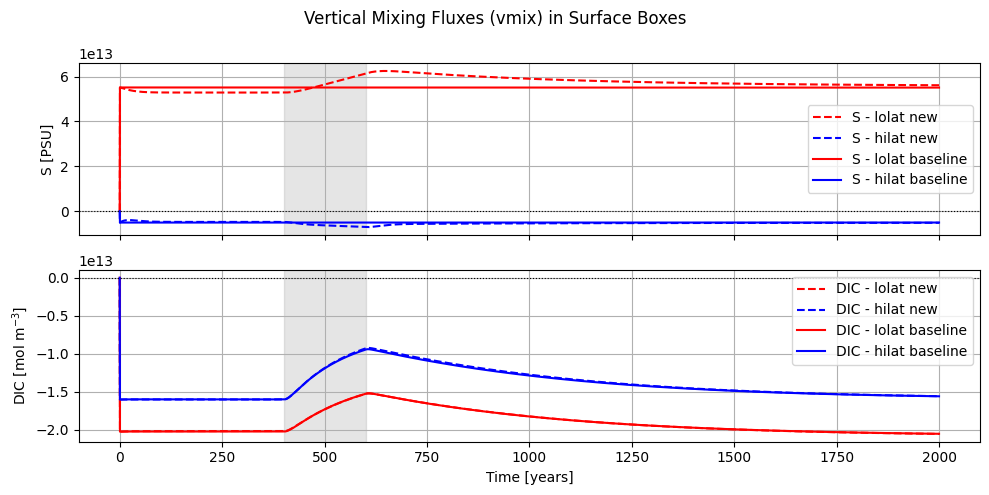

In [151]:
tmax = 2000
dt = 0.5
time = np.arange(0, tmax + dt, dt)

GtC_emissions = np.zeros_like(time)
GtC_emissions[(time > 400) & (time <= 600)] = 8.0  # 8 GtC/yr for 200 years

emit_lolat = init_lolat.copy()
emit_hilat = init_hilat.copy()
emit_deep = init_deep.copy()
emit_atmos = init_atmos.copy()
emit_atmos['GtC_emissions'] = GtC_emissions

new_lolat = emit_lolat.copy()
new_hilat = emit_hilat.copy()
new_deep = emit_deep.copy()
new_atmos = emit_atmos.copy()

# perform new model run
et, elolat, ehilat, edeep, eatmos = test_ocean_model(new_lolat, new_hilat, new_deep, new_atmos, tmax, dt)

baseline_lolat = emit_lolat.copy()
baseline_hilat = emit_hilat.copy()
baseline_deep = emit_deep.copy()
baseline_atmos = emit_atmos.copy()

# perform baseline model run
otime, ololat, ohilat, odeep, oatmos = ocean_model(baseline_lolat, baseline_hilat, baseline_deep, baseline_atmos, tmax, dt)

import matplotlib.pyplot as plt

tracers = ['S', 'DIC']

fig, axs = plt.subplots(len(tracers), 1, figsize=(10, 5), sharex=True)

for i, tracer in enumerate(tracers):
    if i==0:
        unit = 'PSU'
    else:
        unit = r'mol m$^{-3}$'
    axs[i].plot(et, elolat[f'vmix_{tracer}'], label=f'{tracer} - lolat new', linestyle='--', color='red')
    axs[i].plot(et, ehilat[f'vmix_{tracer}'], label=f'{tracer} - hilat new', linestyle='--', color='blue')
    axs[i].plot(otime, ololat[f'vmix_{tracer}'], label=f'{tracer} - lolat baseline', color='red')
    axs[i].plot(otime, ohilat[f'vmix_{tracer}'], label=f'{tracer} - hilat baseline', color='blue')
    axs[i].axvspan(400, 600, color='gray', alpha=0.2)
    axs[i].axhline(0, color='black', linestyle=':', linewidth=0.8)
    axs[i].set_ylabel(f'{tracer} [{unit}]')
    axs[i].legend()
    axs[i].grid(True)

axs[-1].set_xlabel('Time [years]')
fig.suptitle('Vertical Mixing Fluxes (vmix) in Surface Boxes')

plt.savefig('CO2_release_figure_3.png', dpi=1000, bbox_inches='tight')

plt.tight_layout()
plt.show()


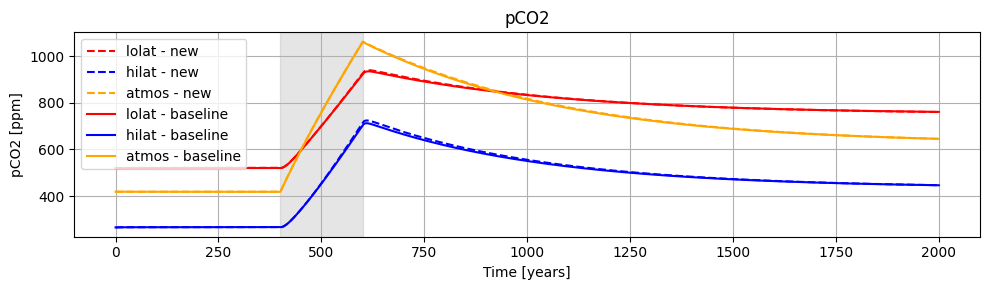

Final pCO₂ (atm):
  Baseline: 645.37 ppm
  Feedback: 645.38 ppm


In [152]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

# pCO2
ax.plot(et, elolat['pCO2'], label='lolat - new', linestyle='--', color='red')
ax.plot(et, ehilat['pCO2'], label='hilat - new', linestyle='--', color='blue')
ax.plot(et, eatmos['pCO2'], label='atmos - new', linestyle='--', color='orange')
ax.plot(et, ololat['pCO2'], label='lolat - baseline', linestyle='-', color='red')
ax.plot(et, ohilat['pCO2'], label='hilat - baseline', linestyle='-', color='blue')
ax.plot(et, oatmos['pCO2'], label='atmos - baseline', linestyle='-', color='orange')
ax.set_ylabel('pCO2 [ppm]')
ax.set_xlabel('Time [years]')
ax.set_title('pCO2')
ax.axvspan(400, 600, color='gray', alpha=0.2)
ax.legend()
ax.grid(True)

plt.savefig('CO2_release_figure_2.png', dpi=1000, bbox_inches='tight')

plt.tight_layout()
plt.show()

print("Final pCO₂ (atm):")
print(f"  Baseline: {oatmos['pCO2'][-1]:.2f} ppm")
print(f"  Feedback: {eatmos['pCO2'][-1]:.2f} ppm")


How does this new feedback mechanism alter the fate of the $\mathrm{CO_2}$ released into the atmosphere? Discuss the mechanisms behind the changes you observe.

How realistic is your simulation of evaporation/precipitation changes? What additional factors might influence how these patterns manifest in the real ocean?

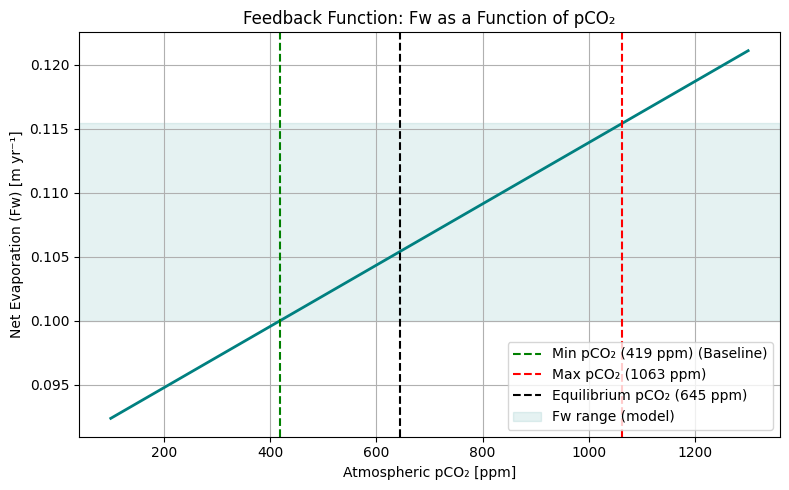

In [153]:
import numpy as np
import matplotlib.pyplot as plt

# Reference CO₂ value (from your baseline run)
pCO2_ref = 418  # ppm
beta = 0.01     # sensitivity factor

# Create a range of pCO₂ values (realistic bounds)
pCO2_vals = np.linspace(100, 1300, 500)

# Calculate corresponding Fw values
Fw_vals = 0.1 + beta * ((pCO2_vals / pCO2_ref) - 1)

# Min and max pCO2 values from the model
pCO2_min = np.min(eatmos['pCO2'])
pCO2_max = np.max(eatmos['pCO2'])
pCO2_last = eatmos['pCO2'][-1]

# Min and max corresponding Fw values
Fw_min = 0.1 + beta * ((pCO2_min / pCO2_ref) - 1)
Fw_max = 0.1 + beta * ((pCO2_max / pCO2_ref) - 1)
Fw_last = 0.1 + beta * ((pCO2_last / pCO2_ref) - 1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(pCO2_vals, Fw_vals, color='teal', linewidth=2)

# Highlight key points
plt.axvline(pCO2_min, color='green', linestyle='--', label=f'Min pCO₂ ({pCO2_min:.0f} ppm) (Baseline)')
plt.axvline(pCO2_max, color='red', linestyle='--', label=f'Max pCO₂ ({pCO2_max:.0f} ppm)')
plt.axvline(pCO2_last, color='black', linestyle='--', label=f'Equilibrium pCO₂ ({pCO2_last:.0f} ppm)')

plt.axhspan(Fw_min, Fw_max, color='teal', alpha=0.1, label='Fw range (model)')

plt.xlabel('Atmospheric pCO₂ [ppm]')
plt.ylabel('Net Evaporation (Fw) [m yr⁻¹]')
plt.title('Feedback Function: Fw as a Function of pCO₂')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('Fw_vs_pCO2.png', dpi=1000, bbox_inches='tight')  # Save the figure
plt.show()